In [1]:
# ============================================================================
# STUDENT DROPOUT PREDICTION - COMPLETE ANALYSIS (NEW DATASET)
# ============================================================================
# Dataset: 1000 students with real dropout labels
# Features: 11 columns with actual missing values and outliers
# ============================================================================

In [2]:
!pip install imbalanced-learn -q
print("✅ Libraries installed!")

✅ Libraries installed!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
print("✅ Libraries imported!")

✅ Libraries imported!


In [4]:
from google.colab import drive
drive.mount('/content/drive')

data_path = "/content/drive/MyDrive/Student_Dropout_Prediction/data/student_data_with_missing_outliers.csv"
df = pd.read_csv(data_path)

print("=" * 80)
print("✅ DATASET LOADED")
print("=" * 80)
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Mounted at /content/drive
✅ DATASET LOADED
Shape: (1000, 11)
Columns: ['student_id', 'age', 'gender', 'department', 'GPA', 'attendance_rate', 'financial_aid', 'parent_education_level', 'hours_studied_per_week', 'internet_access', 'dropout']


In [5]:
# STEP 1 - Handle Missing Values

print("\n" + "=" * 80)
print("STEP 1: HANDLING MISSING VALUES")
print("=" * 80)

print(f"\n📊 Missing values before handling:")
missing_before = df.isnull().sum()
print(missing_before[missing_before > 0])

# Separate column types
numerical_cols = ['GPA', 'attendance_rate', 'hours_studied_per_week', 'age']
categorical_cols = ['gender', 'department', 'financial_aid', 'parent_education_level', 'internet_access']

# Handle numerical missing values with MEDIAN
print(f"\n🔧 Filling numerical columns with median:")
for col in numerical_cols:
    if col in df.columns and df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"   ✓ {col}: filled {missing_before[col]} values with median {median_val:.2f}")

# Handle categorical missing values with MODE
print(f"\n🔧 Filling categorical columns with mode:")
for col in categorical_cols:
    if col in df.columns and df[col].isnull().any():
        mode_val = df[col].mode()[0] if len(df[col].mode()) > 0 else 'Unknown'
        df[col].fillna(mode_val, inplace=True)
        print(f"   ✓ {col}: filled {missing_before[col]} values with mode '{mode_val}'")

print(f"\n✅ Missing values after handling: {df.isnull().sum().sum()}")


STEP 1: HANDLING MISSING VALUES

📊 Missing values before handling:
GPA                        50
attendance_rate            50
financial_aid              50
parent_education_level    157
hours_studied_per_week     49
dtype: int64

🔧 Filling numerical columns with median:
   ✓ GPA: filled 50 values with median 3.06
   ✓ attendance_rate: filled 50 values with median 65.38
   ✓ hours_studied_per_week: filled 49 values with median 12.20

🔧 Filling categorical columns with mode:
   ✓ financial_aid: filled 50 values with mode 'No'
   ✓ parent_education_level: filled 157 values with mode 'Secondary'

✅ Missing values after handling: 0


In [6]:
# STEP 2 - Handle Unrealistic Values
print("\n" + "=" * 80)
print("STEP 2: HANDLING UNREALISTIC VALUES")
print("=" * 80)

# Fix GPA (should be 0-4.0 or 0-5.0)
print(f"\n📌 GPA Analysis:")
print(f"   Original range: [{df['GPA'].min():.2f}, {df['GPA'].max():.2f}]")
invalid_gpa = df[(df['GPA'] < 0) | (df['GPA'] > 5.0)]
print(f"   Invalid GPA values: {len(invalid_gpa)}")

if len(invalid_gpa) > 0:
    # Replace invalid with median of valid values
    valid_gpa = df[(df['GPA'] >= 0) & (df['GPA'] <= 5.0)]['GPA']
    median_gpa = valid_gpa.median()
    df.loc[(df['GPA'] < 0) | (df['GPA'] > 5.0), 'GPA'] = median_gpa
    print(f"   ✓ Replaced {len(invalid_gpa)} invalid values with median {median_gpa:.2f}")
    print(f"   New range: [{df['GPA'].min():.2f}, {df['GPA'].max():.2f}]")

# Fix attendance_rate (should be 0-100)
print(f"\n📌 Attendance Rate Analysis:")
print(f"   Range: [{df['attendance_rate'].min():.2f}, {df['attendance_rate'].max():.2f}]")
invalid_attendance = df[(df['attendance_rate'] < 0) | (df['attendance_rate'] > 100)]
if len(invalid_attendance) > 0:
    print(f"   ⚠️ Found {len(invalid_attendance)} invalid values (fixing...)")
    df.loc[(df['attendance_rate'] < 0) | (df['attendance_rate'] > 100), 'attendance_rate'] = \
        df[(df['attendance_rate'] >= 0) & (df['attendance_rate'] <= 100)]['attendance_rate'].median()
else:
    print(f"   ✓ All values are valid")

# Fix hours_studied_per_week (should be 0-168, but realistically 0-50)
print(f"\n📌 Study Hours Analysis:")
print(f"   Range: [{df['hours_studied_per_week'].min():.2f}, {df['hours_studied_per_week'].max():.2f}]")
extreme_hours = df[df['hours_studied_per_week'] > 50]
if len(extreme_hours) > 0:
    print(f"   ⚠️ Found {len(extreme_hours)} students studying >50 hours/week (capping at 50)")
    df.loc[df['hours_studied_per_week'] > 50, 'hours_studied_per_week'] = 50

print(f"\n✅ All unrealistic values fixed!")


STEP 2: HANDLING UNREALISTIC VALUES

📌 GPA Analysis:
   Original range: [-2.00, 6.50]
   Invalid GPA values: 10
   ✓ Replaced 10 invalid values with median 3.06
   New range: [0.32, 5.00]

📌 Attendance Rate Analysis:
   Range: [30.09, 99.83]
   ✓ All values are valid

📌 Study Hours Analysis:
   Range: [0.00, 70.00]
   ⚠️ Found 9 students studying >50 hours/week (capping at 50)

✅ All unrealistic values fixed!


In [7]:
# STEP 3 - Detect and Handle Outliers

print("\n" + "=" * 80)
print("STEP 3: DETECTING AND HANDLING OUTLIERS")
print("=" * 80)

outlier_cols = ['GPA', 'attendance_rate', 'hours_studied_per_week']

print(f"\n🔍 Using IQR method to detect outliers:")
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"\n{col}:")
    print(f"   Valid range: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"   Outliers found: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

    # Cap outliers
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    print(f"   ✓ Outliers capped to valid range")

print(f"\n✅ All outliers handled!")


STEP 3: DETECTING AND HANDLING OUTLIERS

🔍 Using IQR method to detect outliers:

GPA:
   Valid range: [1.01, 5.04]
   Outliers found: 7 (0.70%)
   ✓ Outliers capped to valid range

attendance_rate:
   Valid range: [-0.57, 132.10]
   Outliers found: 0 (0.00%)
   ✓ Outliers capped to valid range

hours_studied_per_week:
   Valid range: [-1.15, 25.65]
   Outliers found: 13 (1.30%)
   ✓ Outliers capped to valid range

✅ All outliers handled!



STEP 4: CHECKING CLASS IMBALANCE

📊 Original dropout distribution:
dropout
No     766
Yes    234
Name: count, dtype: int64

Percentages:
dropout
No     76.6
Yes    23.4
Name: proportion, dtype: float64

⚖️ Imbalance ratio: 3.27:1
⚠️ Significant imbalance! Will use SMOTE to balance.


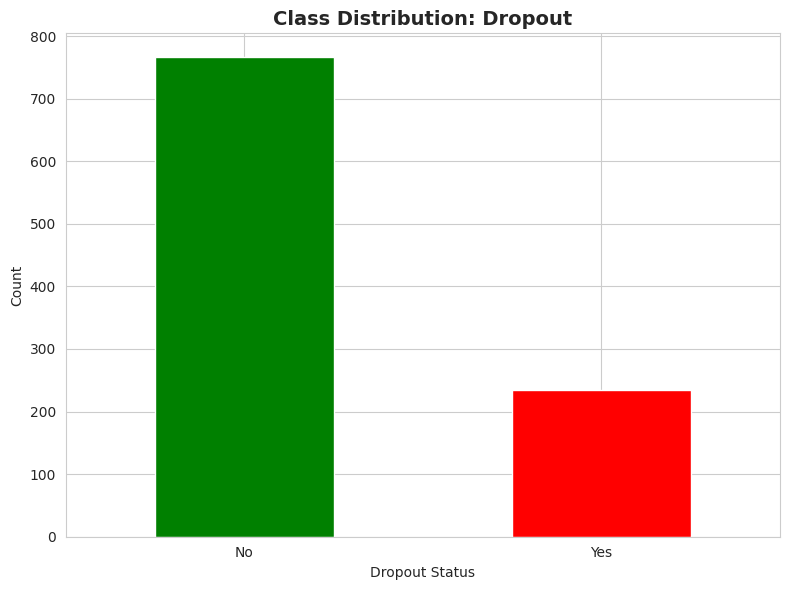

In [8]:
# STEP 4 - Check Class Imbalance

print("\n" + "=" * 80)
print("STEP 4: CHECKING CLASS IMBALANCE")
print("=" * 80)


print(f"\n📊 Original dropout distribution:")
print(df['dropout'].value_counts())
print(f"\nPercentages:")
print(df['dropout'].value_counts(normalize=True) * 100)

# Calculate imbalance ratio
dropout_counts = df['dropout'].value_counts()
imbalance_ratio = dropout_counts.max() / dropout_counts.min()
print(f"\n⚖️ Imbalance ratio: {imbalance_ratio:.2f}:1")

if imbalance_ratio > 2.0:
    print("⚠️ Significant imbalance! Will use SMOTE to balance.")
else:
    print("✓ Imbalance is manageable")

# Visualize
plt.figure(figsize=(8, 6))
df['dropout'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Class Distribution: Dropout', fontsize=14, fontweight='bold')
plt.xlabel('Dropout Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [9]:
# CELL 8: STEP 5 - Encode Categorical Variables

print("\n" + "=" * 80)
print("STEP 5: ENCODING CATEGORICAL VARIABLES")
print("=" * 80)

df_encoded = df.copy()
label_encoders = {}

# Encode categorical features
categorical_to_encode = ['gender', 'department', 'financial_aid',
                         'parent_education_level', 'internet_access']

print(f"\n🔧 Encoding categorical variables:")
for col in categorical_to_encode:
    if col in df_encoded.columns:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
        label_encoders[col] = le

        # Show mapping
        mapping = dict(zip(le.classes_, le.transform(le.classes_)))
        print(f"   ✓ {col}: {mapping}")

# Encode target variable (Yes=1, No=0)
df_encoded['dropout'] = df_encoded['dropout'].map({'Yes': 1, 'No': 0})
print(f"\n✓ Target 'dropout' encoded: Yes=1, No=0")

print(f"\n✅ All encoding complete!")



STEP 5: ENCODING CATEGORICAL VARIABLES

🔧 Encoding categorical variables:
   ✓ gender: {'Female': np.int64(0), 'Male': np.int64(1)}
   ✓ department: {'BA': np.int64(0), 'CE': np.int64(1), 'CS': np.int64(2), 'EE': np.int64(3), 'ME': np.int64(4)}
   ✓ financial_aid: {'No': np.int64(0), 'Yes': np.int64(1)}
   ✓ parent_education_level: {'Primary': np.int64(0), 'Secondary': np.int64(1), 'Tertiary': np.int64(2)}
   ✓ internet_access: {'No': np.int64(0), 'Yes': np.int64(1)}

✓ Target 'dropout' encoded: Yes=1, No=0

✅ All encoding complete!


In [10]:
# STEP 6 - Prepare Data for Modeling

print("\n" + "=" * 80)
print("STEP 6: PREPARING DATA")
print("=" * 80)

# Drop student_id (identifier, not a feature)
if 'student_id' in df_encoded.columns:
    df_encoded = df_encoded.drop('student_id', axis=1)
    print("✓ Dropped 'student_id'")

# Separate features and target
X = df_encoded.drop('dropout', axis=1)
y = df_encoded['dropout']

print(f"\n📊 Feature matrix: {X.shape}")
print(f"📊 Target vector: {y.shape}")
print(f"\n📋 Features: {list(X.columns)}")


STEP 6: PREPARING DATA
✓ Dropped 'student_id'

📊 Feature matrix: (1000, 9)
📊 Target vector: (1000,)

📋 Features: ['age', 'gender', 'department', 'GPA', 'attendance_rate', 'financial_aid', 'parent_education_level', 'hours_studied_per_week', 'internet_access']


In [11]:
# STEP 7 - Train-Test Split

print("\n" + "=" * 80)
print("STEP 7: TRAIN-TEST SPLIT (80/20)")
print("=" * 80)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n✓ Training set: {X_train.shape}")
print(f"  Class distribution: {pd.Series(y_train).value_counts().to_dict()}")

print(f"\n✓ Test set: {X_test.shape}")
print(f"  Class distribution: {pd.Series(y_test).value_counts().to_dict()}")


STEP 7: TRAIN-TEST SPLIT (80/20)

✓ Training set: (800, 9)
  Class distribution: {0: 613, 1: 187}

✓ Test set: (200, 9)
  Class distribution: {0: 153, 1: 47}



STEP 8: BALANCING DATASET WITH SMOTE

Before SMOTE:
  Retained (0): 613
  Dropout (1): 187

After SMOTE:
  Retained (0): 613
  Dropout (1): 613
✓ Training set size: 1226


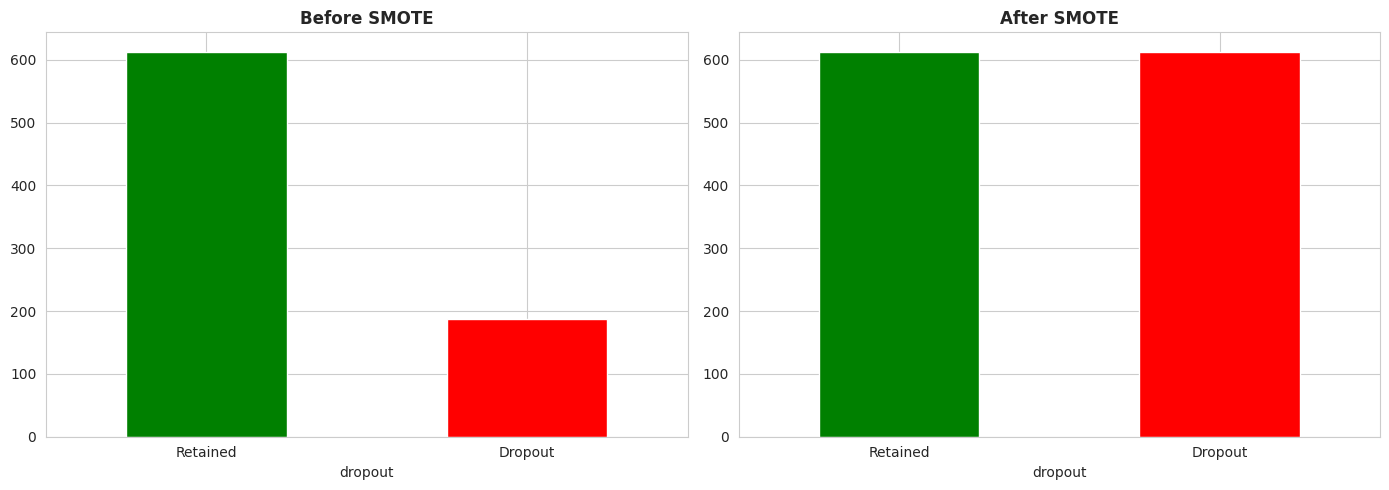

In [12]:

# STEP 8 - Balance Dataset with SMOTE
# =======================================
print("\n" + "=" * 80)
print("STEP 8: BALANCING DATASET WITH SMOTE")
print("=" * 80)

print(f"\nBefore SMOTE:")
print(f"  Retained (0): {sum(y_train == 0)}")
print(f"  Dropout (1): {sum(y_train == 1)}")

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE:")
print(f"  Retained (0): {sum(y_train_balanced == 0)}")
print(f"  Dropout (1): {sum(y_train_balanced == 1)}")
print(f"✓ Training set size: {len(X_train_balanced)}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pd.Series(y_train).value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Before SMOTE', fontsize=12, fontweight='bold')
axes[0].set_xticklabels(['Retained', 'Dropout'], rotation=0)

pd.Series(y_train_balanced).value_counts().plot(kind='bar', ax=axes[1], color=['green', 'red'])
axes[1].set_title('After SMOTE', fontsize=12, fontweight='bold')
axes[1].set_xticklabels(['Retained', 'Dropout'], rotation=0)

plt.tight_layout()
plt.show()

In [13]:
# STEP 9 - Scale Features
# ======================================================
print("\n" + "=" * 80)
print("STEP 9: SCALING FEATURES")
print("=" * 80)

print("\n💡 Why scaling?")
print("   - Features have different scales (GPA: 0-4, attendance: 0-100)")
print("   - StandardScaler: mean=0, std=1")

numerical_features = ['age', 'GPA', 'attendance_rate', 'hours_studied_per_week']

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(X_train_balanced, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test, columns=X.columns)

X_train_scaled[numerical_features] = scaler.fit_transform(X_train_balanced[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])

print(f"\n✓ Scaled features: {numerical_features}")
print(f"✓ Mean after scaling: {X_train_scaled[numerical_features].mean().mean():.4f}")
print(f"✓ Std after scaling: {X_train_scaled[numerical_features].std().mean():.4f}")


STEP 9: SCALING FEATURES

💡 Why scaling?
   - Features have different scales (GPA: 0-4, attendance: 0-100)
   - StandardScaler: mean=0, std=1

✓ Scaled features: ['age', 'GPA', 'attendance_rate', 'hours_studied_per_week']
✓ Mean after scaling: 0.0000
✓ Std after scaling: 1.0004


In [14]:
# STEP 10 - Train Model
# =======================================================
print("\n" + "=" * 80)
print("STEP 10: TRAINING MODEL")
print("=" * 80)

print("\n🤖 Training Random Forest Classifier...")
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_scaled, y_train_balanced)
print("✅ Model trained successfully!")


STEP 10: TRAINING MODEL

🤖 Training Random Forest Classifier...
✅ Model trained successfully!



STEP 11: MODEL EVALUATION

📊 Classification Report:
              precision    recall  f1-score   support

    Retained       0.76      0.76      0.76       153
     Dropout       0.23      0.23      0.23        47

    accuracy                           0.64       200
   macro avg       0.50      0.50      0.50       200
weighted avg       0.64      0.64      0.64       200


🎯 Performance Metrics:
   Accuracy: 0.6400
   ROC-AUC Score: 0.4731


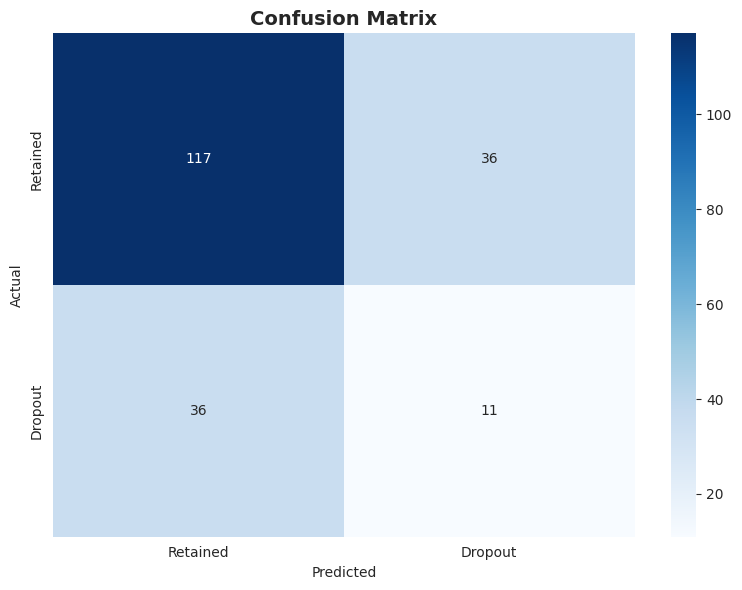


📈 Feature Importance:
               feature  importance
       attendance_rate    0.188666
                   GPA    0.167580
hours_studied_per_week    0.166633
                   age    0.123659
            department    0.117876
parent_education_level    0.074210
                gender    0.073355
         financial_aid    0.056840
       internet_access    0.031181


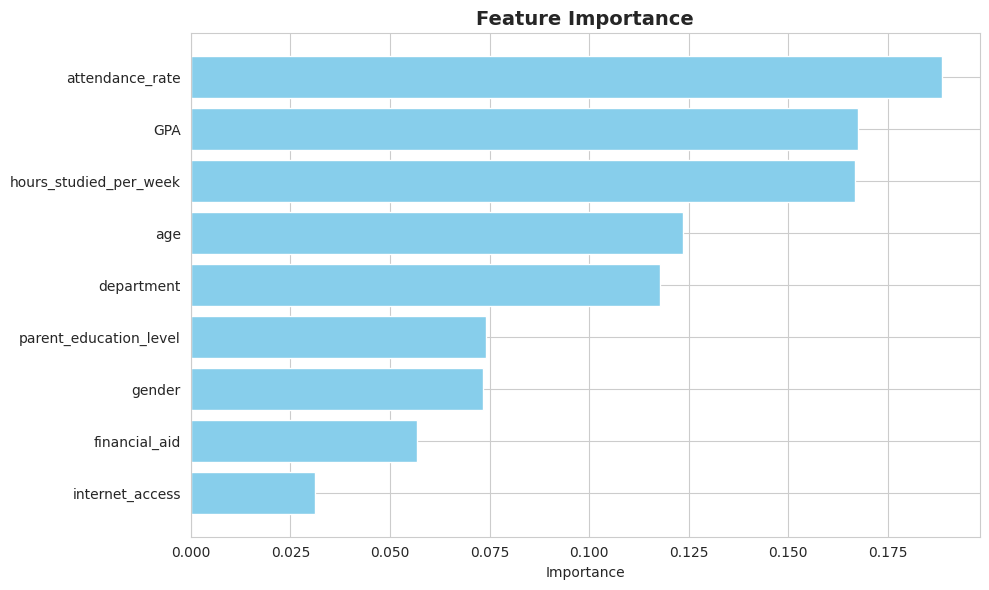

In [15]:

# STEP 11 - Evaluate Model
# ================================
print("\n" + "=" * 80)
print("STEP 11: MODEL EVALUATION")
print("=" * 80)

# Predictions
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n📊 Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Retained', 'Dropout']))

print(f"\n🎯 Performance Metrics:")
print(f"   Accuracy: {accuracy:.4f}")
print(f"   ROC-AUC Score: {roc_auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Retained', 'Dropout'],
            yticklabels=['Retained', 'Dropout'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Feature Importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n📈 Feature Importance:")
print("=" * 60)
print(feature_importance.to_string(index=False))

# Visualize
plt.figure(figsize=(10, 6))
plt.barh(range(len(feature_importance)), feature_importance['importance'], color='skyblue')
plt.yticks(range(len(feature_importance)), feature_importance['feature'])
plt.xlabel('Importance')
plt.title('Feature Importance', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [16]:
# Final Summary
# =========================================
print("\n" + "=" * 80)
print("PROJECT COMPLETE!")
print("=" * 80)

print("\n✅ Preprocessing Steps Completed:")
print("   1. ✓ Handled missing values (median/mode imputation)")
print("   2. ✓ Fixed unrealistic values (GPA, attendance, study hours)")
print("   3. ✓ Detected and capped outliers (IQR method)")
print("   4. ✓ Checked class imbalance (23.4% dropout)")
print("   5. ✓ Encoded categorical variables (5 features)")
print("   6. ✓ Dropped identifier column (student_id)")
print("   7. ✓ Split dataset (80/20 stratified)")
print("   8. ✓ Balanced classes with SMOTE")
print("   9. ✓ Scaled numerical features (StandardScaler)")
print("   10. ✓ Trained Random Forest model")
print("   11. ✓ Evaluated model performance")

print(f"\n📊 Final Results:")
print(f"   Dataset: 1000 students, 10 features")
print(f"   Accuracy: {accuracy:.4f}")
print(f"   ROC-AUC: {roc_auc:.4f}")
print(f"   Training samples: {len(X_train_balanced)}")
print(f"   Test samples: {len(X_test)}")

print(" This dataset had REAL:")
print("   ✓ Missing values (5-15% missing)")
print("   ✓ Outliers (GPA: -2 to 6.5)")
print("   ✓ Dropout labels (23.4% dropout rate)")
print("   ✓ Class imbalance (3.3:1 ratio)")


PROJECT COMPLETE!

✅ Preprocessing Steps Completed:
   1. ✓ Handled missing values (median/mode imputation)
   2. ✓ Fixed unrealistic values (GPA, attendance, study hours)
   3. ✓ Detected and capped outliers (IQR method)
   4. ✓ Checked class imbalance (23.4% dropout)
   5. ✓ Encoded categorical variables (5 features)
   6. ✓ Dropped identifier column (student_id)
   7. ✓ Split dataset (80/20 stratified)
   8. ✓ Balanced classes with SMOTE
   9. ✓ Scaled numerical features (StandardScaler)
   10. ✓ Trained Random Forest model
   11. ✓ Evaluated model performance

📊 Final Results:
   Dataset: 1000 students, 10 features
   Accuracy: 0.6400
   ROC-AUC: 0.4731
   Training samples: 1226
   Test samples: 200
 This dataset had REAL:
   ✓ Missing values (5-15% missing)
   ✓ Outliers (GPA: -2 to 6.5)
   ✓ Dropout labels (23.4% dropout rate)
   ✓ Class imbalance (3.3:1 ratio)
